In [2]:
import pandas as pd
import numpy as np
import sklearn.datasets as make_classification

In [4]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=100,
    n_features=5,
    n_redundant=0,
    n_informative=5,
    n_clusters_per_class=1
)

print(X.shape)
print(y.shape)

(100, 5)
(100,)


In [6]:
df = pd.DataFrame(X, columns=["col1","col2","col3","col4","col5"])
df["targets"] = y
print(df.shape)

df.head()

(100, 6)


,col1,col2,col3,col4,col5,targets
0,-1.423196,2.868334,0.238617,0.810042,2.709513,0
1,-0.657394,1.337548,-0.159772,1.197703,2.444047,1
2,-1.143097,-1.330656,2.514631,2.022941,0.875413,0
3,0.722790,-4.770012,2.576218,2.876516,0.302149,0
4,-4.754440,2.603475,-0.760282,1.875527,-1.116991,1


In [17]:
import pandas as pd

def row_sampling(df, percent):
    n_rows = int(percent * df.shape[0])
    return df.sample(n=n_rows, replace=True)



In [70]:
# function for feature sampling
import random
def feature_sampling(df, percent):
  col = random.sample(df.columns.tolist()[:-1], int(percent*df.shape[1] -1))
  return df[col]

In [19]:
# function for combination sampling

def combination_sampling(df, row_sample, feature_sample):
  new_df = row_sampling(df, row_sample)
  return feature_sampling(new_df, feature_sample)

In [57]:
df1 = row_sampling(df, 0.2)

In [58]:
df2 = row_sampling(df,0.2)

In [59]:
df3 = row_sampling(df, 0.2)

In [60]:
# create object

from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [61]:
clf1.fit(df1.iloc[:, :-1], df1.iloc[:, -1])
clf2.fit(df2.iloc[:, :-1], df2.iloc[:, -1])
clf3.fit(df3.iloc[:, :-1], df3.iloc[:, -1])

DecisionTreeClassifier()

In [62]:
from sklearn.tree import plot_tree

[Text(0.4, 0.8333333333333334, 'x[1] <= 0.366\ngini = 0.495\nsamples = 20\nvalue = [11, 9]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 9\nvalue = [9, 0]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[2] <= 1.146\ngini = 0.298\nsamples = 11\nvalue = [2, 9]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 9\nvalue = [0, 9]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]')]

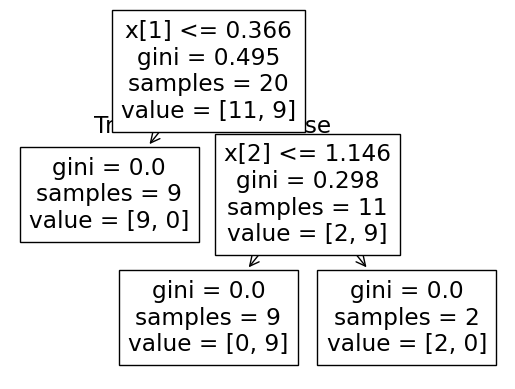

In [63]:
plot_tree(clf1)

[Text(0.4, 0.8333333333333334, 'x[1] <= 0.203\ngini = 0.495\nsamples = 20\nvalue = [9, 11]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 8\nvalue = [8, 0]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[2] <= 1.418\ngini = 0.153\nsamples = 12\nvalue = [1, 11]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 11\nvalue = [0, 11]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]')]

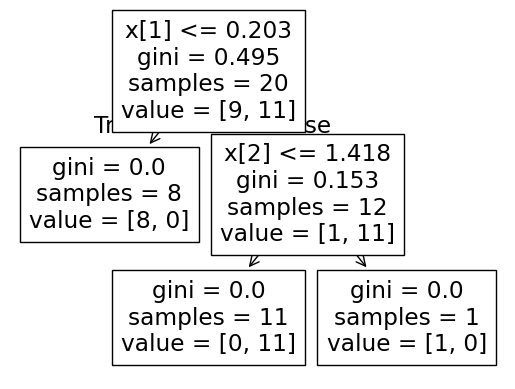

In [64]:
plot_tree(clf2)

[Text(0.375, 0.875, 'x[1] <= -0.969\ngini = 0.495\nsamples = 20\nvalue = [9, 11]'),
 Text(0.25, 0.625, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.3125, 0.75, 'True  '),
 Text(0.5, 0.625, 'x[4] <= 1.58\ngini = 0.391\nsamples = 15\nvalue = [4, 11]'),
 Text(0.4375, 0.75, '  False'),
 Text(0.25, 0.375, 'x[0] <= -2.655\ngini = 0.165\nsamples = 11\nvalue = [1, 10]'),
 Text(0.125, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.375, 0.125, 'gini = 0.0\nsamples = 10\nvalue = [0, 10]'),
 Text(0.75, 0.375, 'x[2] <= -0.015\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.625, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.875, 0.125, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]')]

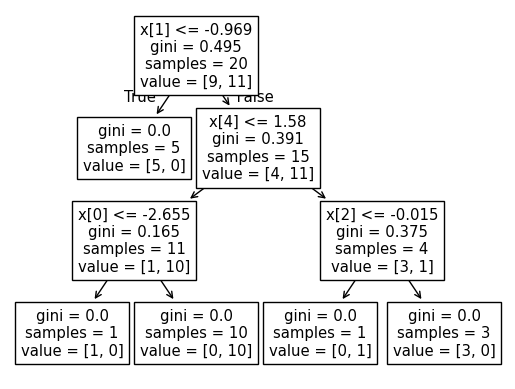

In [65]:
plot_tree(clf3)

In [66]:
df.head()

,col1,col2,col3,col4,col5,targets
0,-1.423196,2.868334,0.238617,0.810042,2.709513,0
1,-0.657394,1.337548,-0.159772,1.197703,2.444047,1
2,-1.143097,-1.330656,2.514631,2.022941,0.875413,0
3,0.722790,-4.770012,2.576218,2.876516,0.302149,0
4,-4.754440,2.603475,-0.760282,1.875527,-1.116991,1


In [67]:

clf1.predict(np.array([-1.423196,	2.868334,	0.238617,	0.810042,	2.709513	]).reshape(1,5))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [68]:
clf2.predict(np.array([-1.423196,	2.868334,	0.238617,	0.810042,	2.709513	]).reshape(1,5))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [69]:
clf2.predict(np.array([-1.423196,	2.868334,	0.238617,	0.810042,	2.709513	]).reshape(1,5))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])